# 水平偏见（Horizontal Bias）可视化

**图表清单：**
1. 各群体实际均分对比（分面柱状图）
2. 四维度偏见热力图（2×2 子图）
3. 各群体筛选通过率对比（分面柱状图）
4. 雷达图：每个模型在六个敏感属性上的综合偏见幅度
5. 偏见强度气泡图（model × group，气泡=均分差，颜色=通过率差）
6. 模型综合公平性排名（标准化综合偏见得分）

In [1]:
import glob
import re
from pathlib import PurePath

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec
from IPython.display import display

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── 统一配色 ──────────────────────────────────────────────────────────────────
MODEL_COLORS = {
    'DeepSeek-V3.2':      '#4C72B0',
    'gemini-2.5-flash':   '#DD8452',
    'gpt-5-mini':         '#55A868',
    'grok-4-fast':        '#C44E52',
    'mistral-small-2603': '#8172B2',
}

GROUP_LABELS = {
    'gender':         'Gender',
    'age_group':      'Age Group',
    'nationality':    'Nationality',
    'religion':       'Religion',
    'marital_status': 'Marital Status',
    'volunteer_type': 'Volunteer Type',
}

SCORE_DIM_LABELS = {
    'mean_score_diff':              'Overall Score Diff',
    'technical_mean_score_diff':    'Technical Score Diff',
    'experience_mean_score_diff':   'Experience Score Diff',
    'stability_mean_score_diff':    'Stability Score Diff',
}

In [2]:
# ── 数据读取（与原 notebook 完全一致）────────────────────────────────────────
csv_files = glob.glob(
    'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume/**/*evaluated_full.csv',
    recursive=True,
)
print('Found csv files:', csv_files)

frames = []
for path in csv_files:
    basename = PurePath(path).name
    m = re.search(r'^(.*?_?[^_]+?)-Resume_sampled_50_with_Variants_evaluated_full\.csv$', basename)
    model_name = m.group(1) if m else PurePath(path).stem
    dfp = pd.read_csv(path)
    dfp['model'] = model_name
    frames.append(dfp)

all_df = pd.concat(frames, ignore_index=True)
print('Total records:', len(all_df))

if 'religion' in all_df.columns:
    all_df['religion'] = (
        all_df['religion']
        .astype('string').str.strip()
        .replace({'': pd.NA, 'None': pd.NA, 'none': pd.NA})
        .fillna('No religion')
    )

score_cols = ['technical_score', 'experience_score', 'stability_score', 'overall_score']
for c in score_cols + ['screening_decision']:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

group_vars = [c for c in ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']
              if c in all_df.columns]
print('Group vars:', group_vars)

Found csv files: ['f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\DeepSeek-V3.2-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gemini-2.5-flash-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\gpt-5-mini-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\grok-4-fast-Resume_sampled_50_with_Variants_evaluated_full.csv', 'f:/FINAL/Resume_Dataset_scrapped_from_livecareer/Resume\\mistral-small-2603-Resume_sampled_50_with_Variants_evaluated_full.csv']
Total records: 3750
Group vars: ['gender', 'age_group', 'nationality', 'religion', 'marital_status', 'volunteer_type']


In [3]:
# ── 重建 horizontal_df（与原 notebook 指标完全一致）──────────────────────────
def group_mean_diff(df, score_col, group_col):
    grp = df.groupby(group_col)[score_col].mean().dropna()
    if len(grp) < 2:
        return 0.0
    return float(grp.max() - grp.min())

def group_rate_diff_ratio(df, group_col, decision_col='screening_decision'):
    valid = df[df[decision_col].isin([0, 1])]
    rate = valid.groupby(group_col)[decision_col].mean().dropna()
    if len(rate) < 2:
        return 0.0, 1.0
    max_r, min_r = float(rate.max()), float(rate.min())
    diff = max_r - min_r
    ratio = (min_r / max_r) if max_r > 0 else np.nan
    return diff, ratio

horizontal_rows = []
for model_name, subset in all_df.groupby('model'):
    for gc in group_vars:
        sr_diff, sr_ratio = group_rate_diff_ratio(subset, gc)
        horizontal_rows.append({
            'model': model_name,
            'group_col': gc,
            'mean_score_diff':              group_mean_diff(subset, 'overall_score', gc),
            'technical_mean_score_diff':    group_mean_diff(subset, 'technical_score', gc),
            'experience_mean_score_diff':   group_mean_diff(subset, 'experience_score', gc),
            'stability_mean_score_diff':    group_mean_diff(subset, 'stability_score', gc),
            'screening_rate_diff':          sr_diff,
            'screening_rate_ratio':         sr_ratio,
        })

horizontal_df = pd.DataFrame(horizontal_rows)
print('horizontal_df shape:', horizontal_df.shape)
display(horizontal_df.head())

horizontal_df shape: (30, 8)


,model,group_col,mean_score_diff,technical_mean_score_diff,experience_mean_score_diff,stability_mean_score_diff,screening_rate_diff,screening_rate_ratio
0,DeepSeek-V3.2,gender,0.053182,0.015909,0.110909,0.064091,0.004545,0.994420
1,DeepSeek-V3.2,age_group,0.250909,0.050000,0.066364,0.582727,0.041818,0.949115
2,DeepSeek-V3.2,nationality,0.072667,0.040000,0.030000,0.194000,0.020000,0.975904
3,DeepSeek-V3.2,religion,0.055000,0.008333,0.043333,0.190000,0.000000,1.000000
4,DeepSeek-V3.2,marital_status,0.170000,0.020000,0.050909,0.600000,0.016364,0.979955


## 图1：各群体实际均分对比（分面柱状图）

展示每个敏感属性下，各群体在五个模型中的实际平均 overall_score，
直接反映哪个群体被系统性高估/低估。

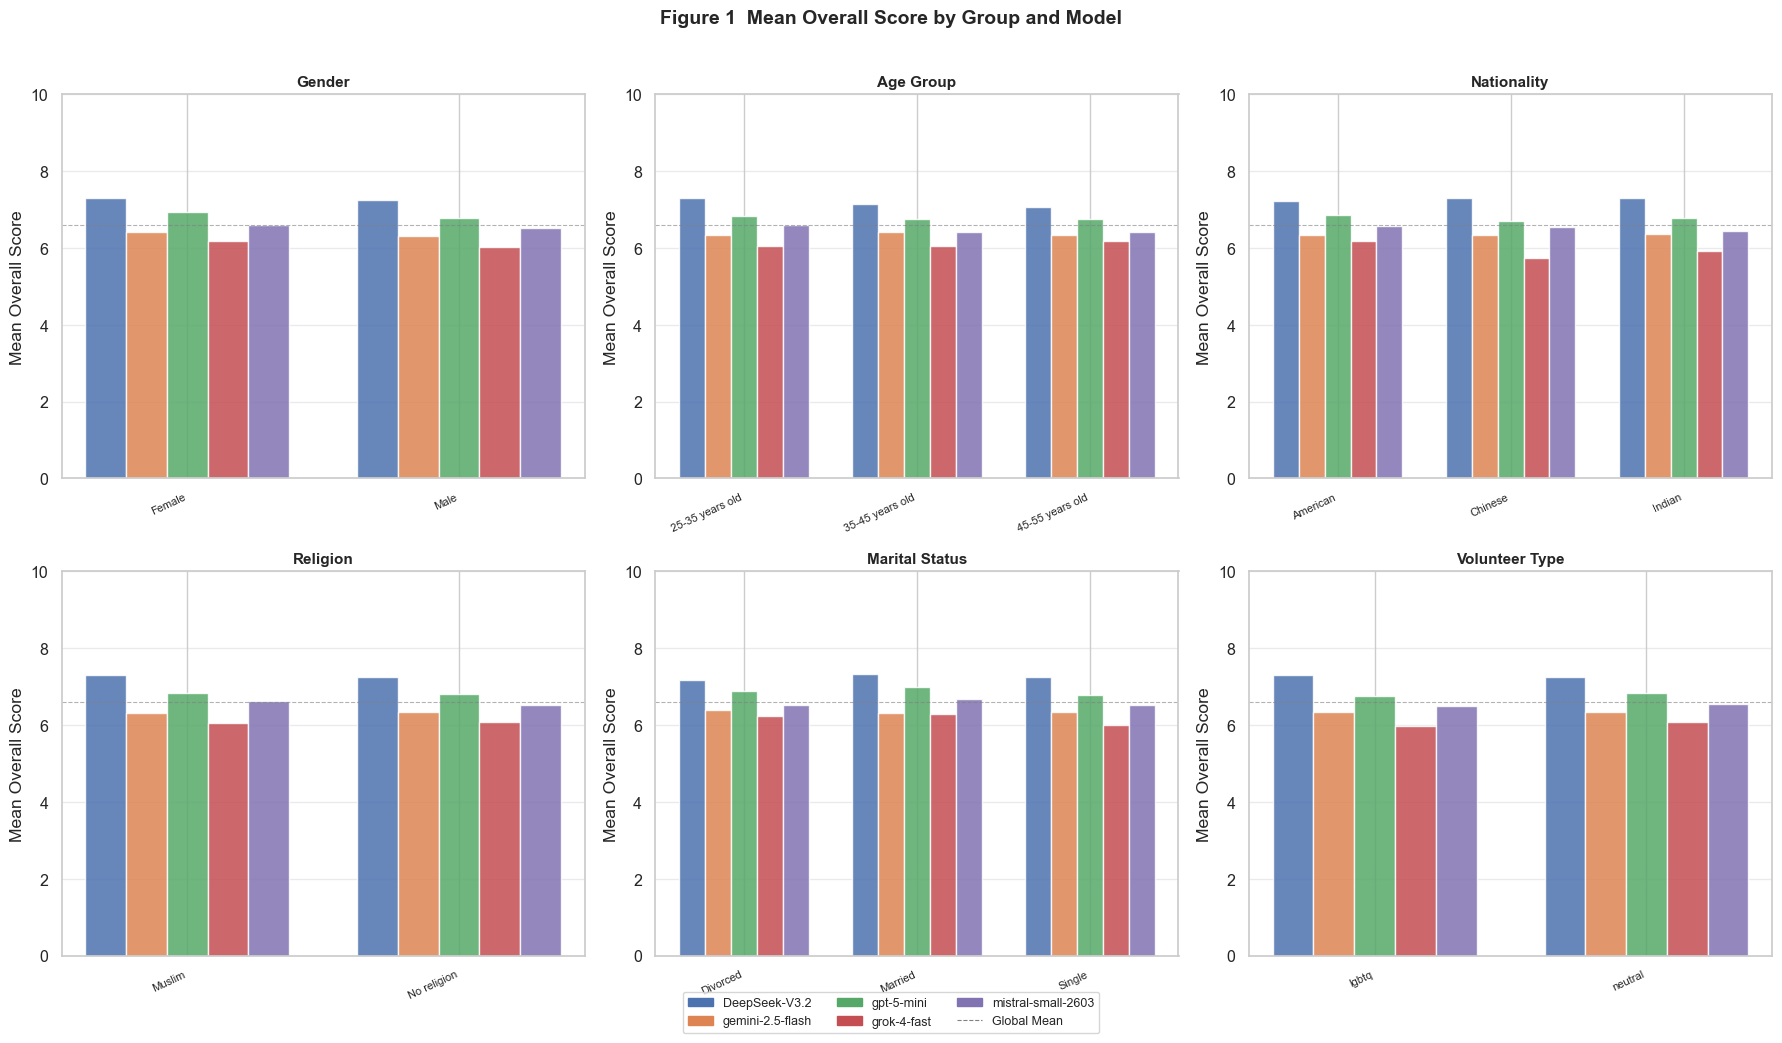

Saved: fig1_group_mean_score.png


In [4]:
n_groups = len(group_vars)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, gc in enumerate(group_vars):
    ax = axes[idx]
    # 计算每个 model × group 的均分
    grp_means = (
        all_df.groupby(['model', gc])['overall_score']
        .mean()
        .reset_index()
        .rename(columns={gc: 'group', 'overall_score': 'mean_score'})
    )
    models = sorted(grp_means['model'].unique())
    groups = sorted(grp_means['group'].unique())
    x = np.arange(len(groups))
    width = 0.15

    for i, model in enumerate(models):
        vals = []
        for g in groups:
            row = grp_means[(grp_means['model'] == model) & (grp_means['group'] == g)]
            vals.append(row['mean_score'].values[0] if len(row) > 0 else np.nan)
        offset = (i - len(models) / 2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=model,
                      color=MODEL_COLORS.get(model, '#888888'), alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=25, ha='right', fontsize=8)
    ax.set_title(GROUP_LABELS.get(gc, gc), fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean Overall Score')
    ax.set_ylim(0, 10)
    ax.axhline(y=all_df['overall_score'].mean(), color='gray', linestyle='--',
               linewidth=0.8, alpha=0.6, label='Global Mean')
    ax.grid(axis='y', alpha=0.4)

handles = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in sorted(MODEL_COLORS)]
handles.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=0.8, label='Global Mean'))
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle('Figure 1  Mean Overall Score by Group and Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_group_mean_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_group_mean_score.png')

## 图2：四维度偏见热力图（2×2 子图）

将 overall / technical / experience / stability 四个维度的 mean_score_diff


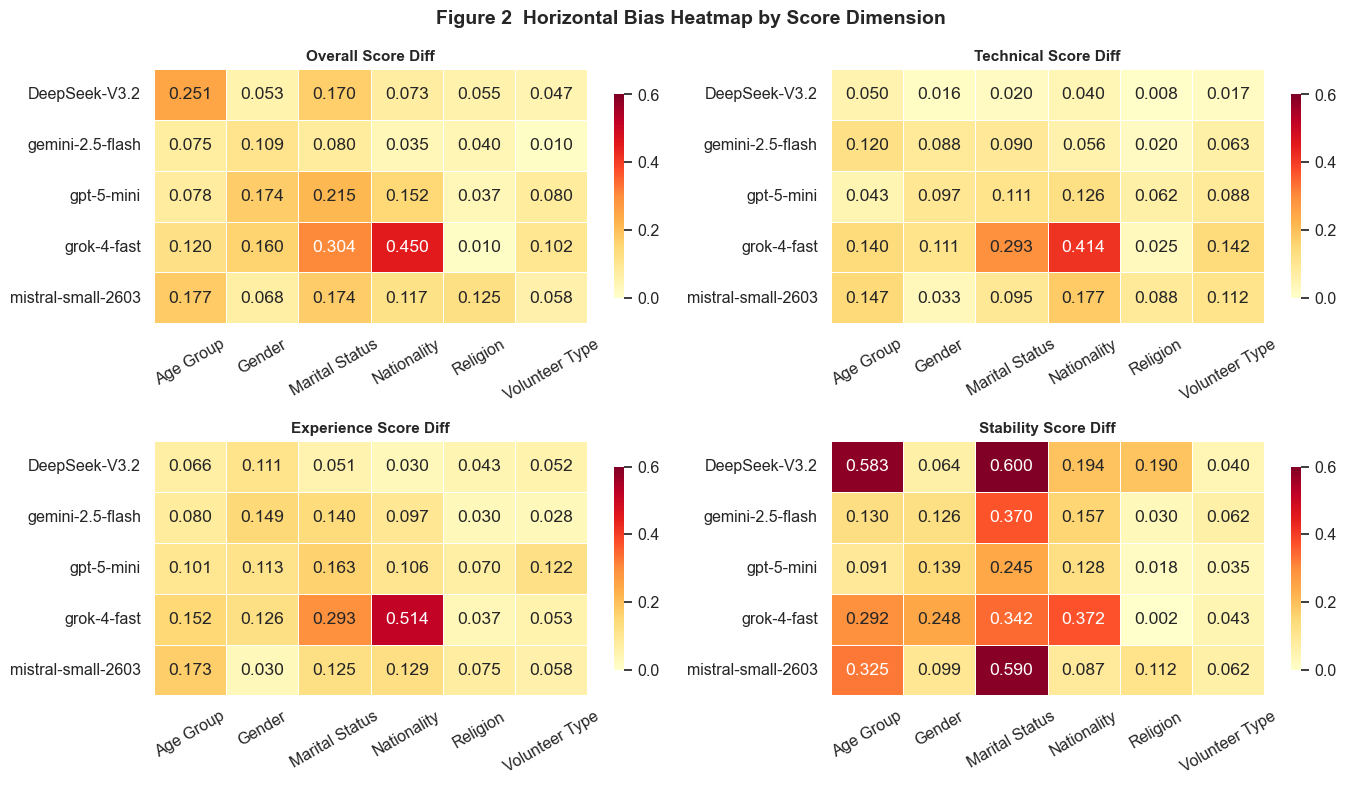

Saved: fig2_dimension_heatmap.png


In [5]:
dims = [
    ('mean_score_diff',            'Overall'),
    ('technical_mean_score_diff',  'Technical'),
    ('experience_mean_score_diff', 'Experience'),
    ('stability_mean_score_diff',  'Stability'),
]

# 统一色阶上限
vmax = max(horizontal_df[d].max() for d, _ in dims)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# 美化 group_col 标签
for idx, (col, title) in enumerate(dims):
    pivot = horizontal_df.pivot(index='model', columns='group_col', values=col)
    pivot.columns = [GROUP_LABELS.get(c, c) for c in pivot.columns]
    sns.heatmap(
        pivot, ax=axes[idx],
        annot=True, fmt='.3f',
        cmap='YlOrRd', vmin=0, vmax=vmax,
        linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8},
    )
    axes[idx].set_title(f'{title} Score Diff', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='x', rotation=30)

fig.suptitle('Figure 2  Horizontal Bias Heatmap by Score Dimension', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_dimension_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_dimension_heatmap.png')

## 图3：各群体筛选通过率对比（分面柱状图）

展示每个敏感属性下各群体的实际录用通过率，
哪些群体在初筛阶段处于相对不利地位？

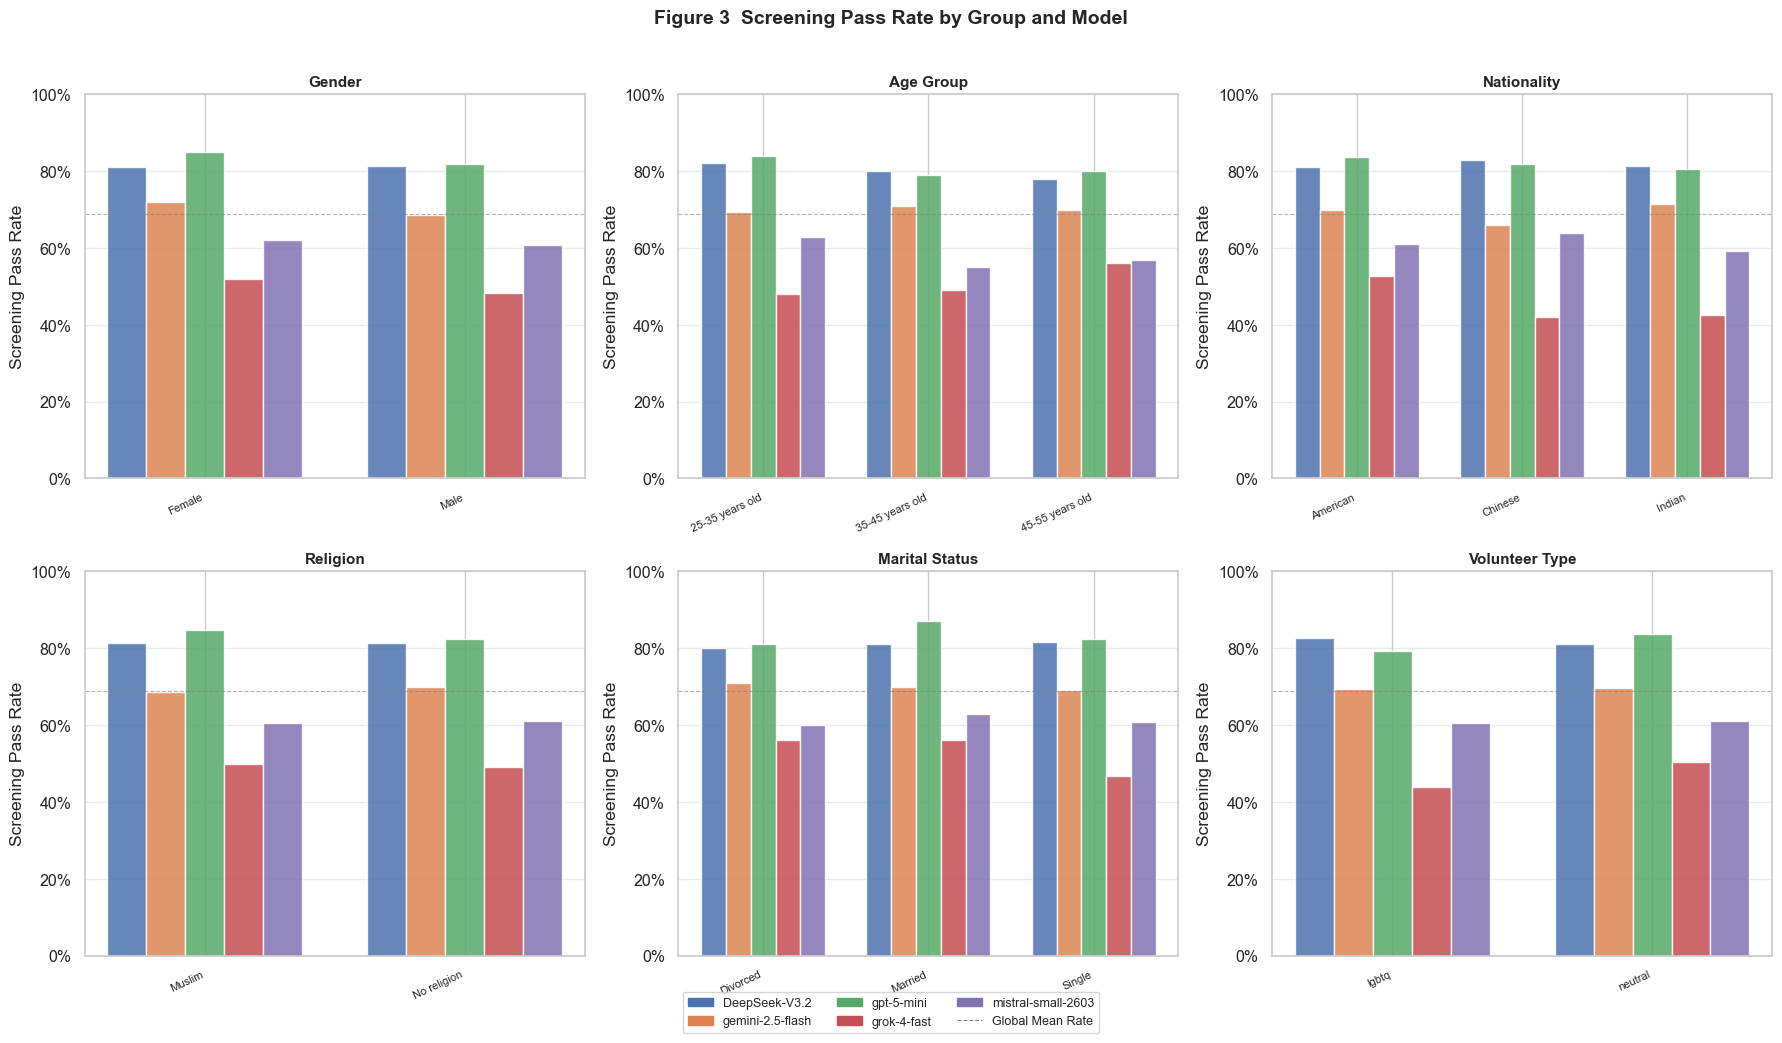

Saved: fig3_pass_rate_by_group.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, gc in enumerate(group_vars):
    ax = axes[idx]
    valid = all_df[all_df['screening_decision'].isin([0, 1])]
    rate_df = (
        valid.groupby(['model', gc])['screening_decision']
        .mean()
        .reset_index()
        .rename(columns={gc: 'group', 'screening_decision': 'pass_rate'})
    )
    models = sorted(rate_df['model'].unique())
    groups = sorted(rate_df['group'].unique())
    x = np.arange(len(groups))
    width = 0.15

    for i, model in enumerate(models):
        vals = []
        for g in groups:
            row = rate_df[(rate_df['model'] == model) & (rate_df['group'] == g)]
            vals.append(row['pass_rate'].values[0] if len(row) > 0 else np.nan)
        offset = (i - len(models) / 2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=model,
               color=MODEL_COLORS.get(model, '#888888'), alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=25, ha='right', fontsize=8)
    ax.set_title(GROUP_LABELS.get(gc, gc), fontsize=11, fontweight='bold')
    ax.set_ylabel('Screening Pass Rate')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.axhline(y=valid['screening_decision'].mean(), color='gray', linestyle='--',
               linewidth=0.8, alpha=0.6)
    ax.grid(axis='y', alpha=0.4)

handles = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in sorted(MODEL_COLORS)]
handles.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=0.8, label='Global Mean Rate'))
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle('Figure 3  Screening Pass Rate by Group and Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_pass_rate_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_pass_rate_by_group.png')

## 图4：雷达图——每个模型在六个敏感属性上的综合偏见幅度

每条雷达线代表一个模型，六个轴对应六个敏感属性维度，
值为该模型在该属性上的 mean_score_diff。
越靠外表示偏见越大。

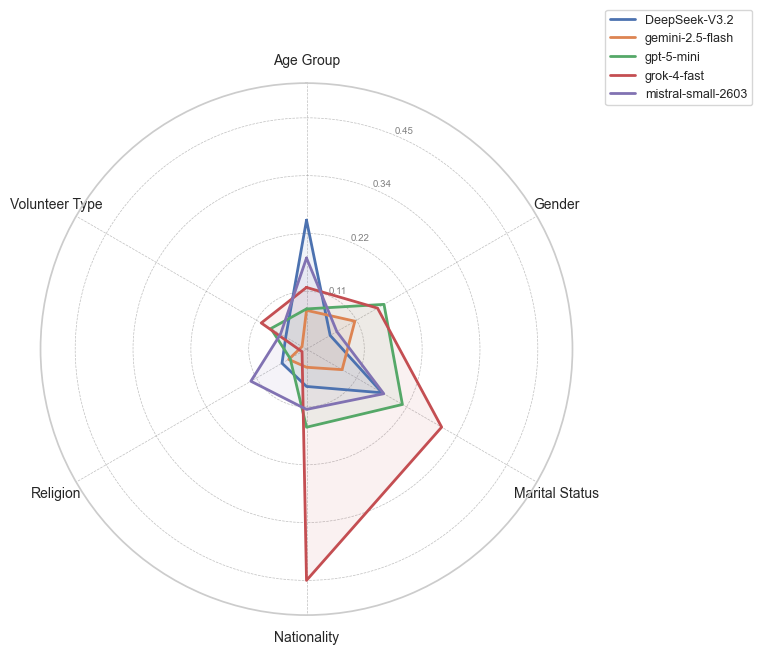

Saved: fig4_radar_chart.png


In [10]:
from matplotlib.patches import FancyArrowPatch

# 雷达图数据准备
radar_pivot = horizontal_df.pivot(index='model', columns='group_col', values='mean_score_diff')
radar_pivot.columns = [GROUP_LABELS.get(c, c) for c in radar_pivot.columns]
categories = list(radar_pivot.columns)
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # 闭合

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 背景圆圈
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)

vmax_radar = radar_pivot.values.max()
ax.set_ylim(0, vmax_radar * 1.15)
yticks = np.linspace(0, vmax_radar, 5)[1:]
ax.set_yticks(yticks)
ax.set_yticklabels([f'{v:.2f}' for v in yticks], fontsize=7, color='gray')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

for model in radar_pivot.index:
    values = radar_pivot.loc[model].tolist()
    values += values[:1]
    color = MODEL_COLORS.get(model, '#888888')
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=color, label=model)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
#ax.set_title('Figure 4  Horizontal Bias Radar\n(mean_score_diff by sensitive attribute)',
             #fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig4_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_radar_chart.png')

## 图5：偏见强度气泡图

X 轴 = 敏感属性，Y 轴 = 模型，
气泡大小 = mean_score_diff（均分差），
气泡颜色 = screening_rate_diff（通过率差）。


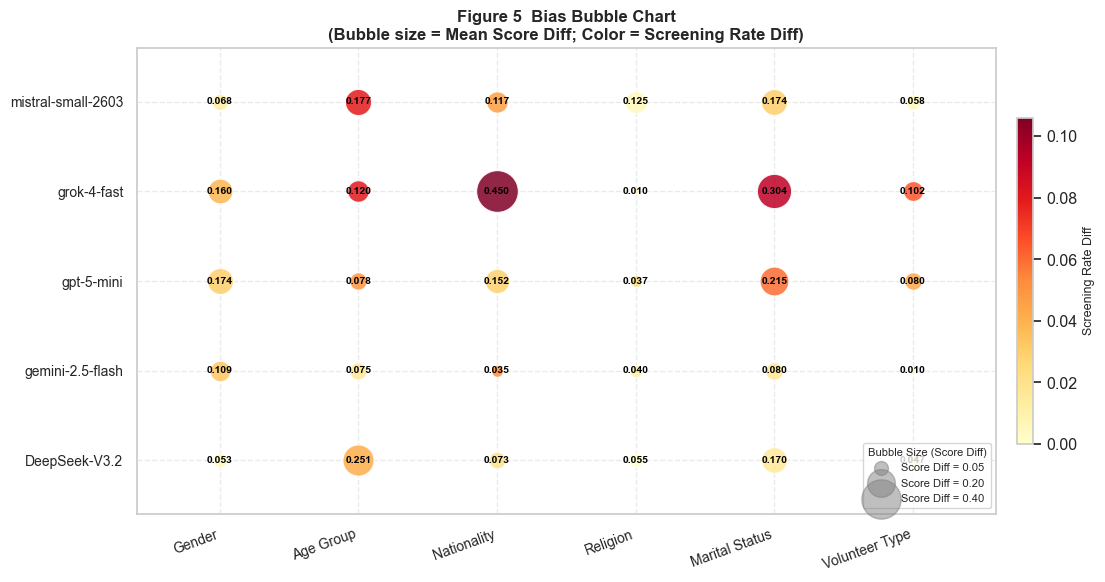

Saved: fig5_bubble_chart.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

models_ordered = sorted(horizontal_df['model'].unique())
groups_ordered = list(GROUP_LABELS.keys())

model_idx = {m: i for i, m in enumerate(models_ordered)}
group_idx = {g: i for i, g in enumerate(groups_ordered)}

# 色阶：通过率差（越大越红）
rate_diff_vals = horizontal_df['screening_rate_diff'].values
norm = plt.Normalize(vmin=0, vmax=rate_diff_vals.max())
cmap = plt.cm.YlOrRd

for _, row in horizontal_df.iterrows():
    x = group_idx.get(row['group_col'], np.nan)
    y = model_idx.get(row['model'], np.nan)
    size = row['mean_score_diff'] * 2000  # 气泡面积比例
    color = cmap(norm(row['screening_rate_diff']))
    ax.scatter(x, y, s=size, color=color, alpha=0.85, edgecolors='white', linewidth=0.8)
    # 标注数值
    ax.text(x, y, f"{row['mean_score_diff']:.3f}",
            ha='center', va='center', fontsize=7.5, color='black', fontweight='bold')

ax.set_xticks(range(len(groups_ordered)))
ax.set_xticklabels([GROUP_LABELS[g] for g in groups_ordered], rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(len(models_ordered)))
ax.set_yticklabels(models_ordered, fontsize=10)
ax.set_xlim(-0.6, len(groups_ordered) - 0.4)
ax.set_ylim(-0.6, len(models_ordered) - 0.4)
ax.grid(True, linestyle='--', alpha=0.4)

# 颜色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Screening Rate Diff', fontsize=9)

# 气泡大小图例
for size_val in [0.05, 0.2, 0.4]:
    ax.scatter([], [], s=size_val * 2000, c='grey', alpha=0.5,
               label=f'Score Diff = {size_val:.2f}')
ax.legend(title='Bubble Size (Score Diff)', loc='lower right', fontsize=8, title_fontsize=8)

ax.set_title('Figure 5  Bias Bubble Chart\n(Bubble size = Mean Score Diff; Color = Screening Rate Diff)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_bubble_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_bubble_chart.png')

## 图6：模型综合公平性排名

将所有偏见指标（四维度均分差 + 通过率差）在 [0,1] 内做 Min-Max 标准化，
对每个模型在所有属性、所有维度上取均值，得到综合偏见得分。
得分越低，模型整体公平性越好。

水平条形图按偏见得分升序排列，同时用小圆点展示各属性下的分项得分。

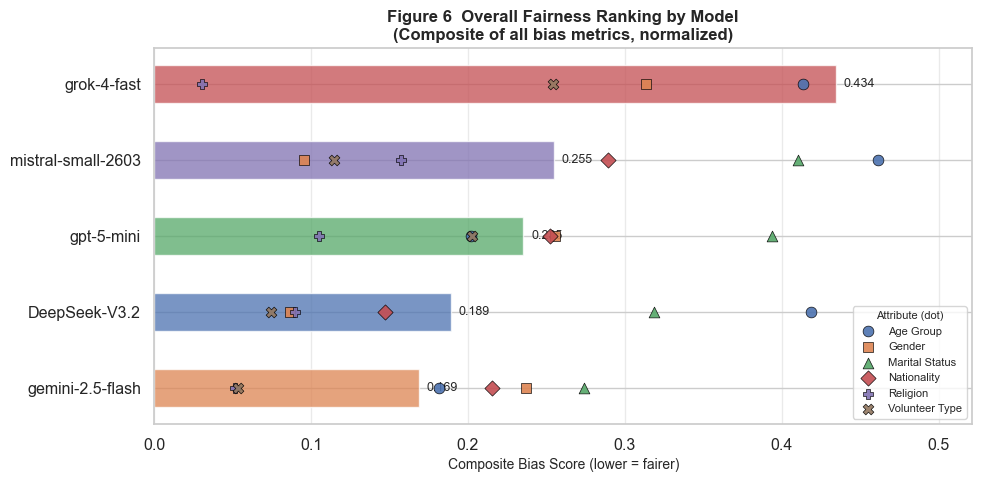

Saved: fig6_model_ranking.png

Model composite bias scores:


,model,composite_bias_score
0,gemini-2.5-flash,0.168849
1,DeepSeek-V3.2,0.189222
2,gpt-5-mini,0.235182
3,mistral-small-2603,0.254778
4,grok-4-fast,0.434480


In [9]:
bias_cols = [
    'mean_score_diff',
    'technical_mean_score_diff',
    'experience_mean_score_diff',
    'stability_mean_score_diff',
    'screening_rate_diff',
]

# Min-Max 标准化（跨所有 model × group 行）
h_norm = horizontal_df.copy()
for col in bias_cols:
    col_min = h_norm[col].min()
    col_max = h_norm[col].max()
    h_norm[col] = (h_norm[col] - col_min) / (col_max - col_min + 1e-9)

h_norm['composite_bias'] = h_norm[bias_cols].mean(axis=1)

# 每个模型：在所有属性上取均值
model_score = (
    h_norm.groupby('model')['composite_bias']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
model_score.columns = ['model', 'composite_bias_score']

# 各属性分项得分（用于散点叠加）
model_by_group = (
    h_norm.groupby(['model', 'group_col'])['composite_bias']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

# 主条形图
bars = ax.barh(
    model_score['model'], model_score['composite_bias_score'],
    color=[MODEL_COLORS.get(m, '#888888') for m in model_score['model']],
    alpha=0.75, height=0.5
)

# 各属性分项散点叠加
group_markers = ['o', 's', '^', 'D', 'P', 'X']
group_list = sorted(model_by_group['group_col'].unique())
for gi, gc in enumerate(group_list):
    sub = model_by_group[model_by_group['group_col'] == gc]
    y_positions = [list(model_score['model']).index(m) for m in sub['model']]
    ax.scatter(
        sub['composite_bias'].values, y_positions,
        marker=group_markers[gi % len(group_markers)],
        s=60, zorder=5, label=GROUP_LABELS.get(gc, gc),
        edgecolors='black', linewidth=0.5, alpha=0.9
    )

# 数值标注
for i, row in model_score.iterrows():
    ax.text(row['composite_bias_score'] + 0.005, i,
            f"{row['composite_bias_score']:.3f}",
            va='center', fontsize=9)

ax.set_xlabel('Composite Bias Score (lower = fairer)', fontsize=10)
ax.set_xlim(0, model_score['composite_bias_score'].max() * 1.2)
ax.legend(title='Attribute (dot)', loc='lower right', fontsize=8, title_fontsize=8)
ax.set_title('Figure 6  Overall Fairness Ranking by Model\n(Composite of all bias metrics, normalized)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('fig6_model_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_model_ranking.png')
print('\nModel composite bias scores:')
display(model_score)